In [1]:
import platform

if platform.system() == "Linux":
    # Install portaudio development libraries for simpleaudio to build successfully on Linux
    !apt-get update
    !apt-get install -y portaudio19-dev
else:
    print(f"Skipping portaudio installation as this is not a Linux environment: {platform.system()}")


Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.3 MB]
Hit:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,605 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,311 kB]
Hit:13 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:14 http://archive.ubunt

In [2]:
pip install simpleaudio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 36.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for simpleaudio: filename=simpleaudio-1.0.4-cp312-cp312-linux_x86_64.whl size=2054639 sha256=a1df5208944859d68e8c35607332556ec599edd3e06c6c4593108a74268bff29
  Stored in directory: /root/.cache/pip/wheels/1d/ad/93/be934a93f1ba8922256840f1cf0e59f8a21e2539985616b64f
Successfully built simpleaudio


In [ ]:
import simpleaudio as sa
filename = 'Promenade_org.wav'
wave_obj = sa.WaveObject.from_wave_file(filename)
play_obj = wave_obj.play()
play_obj.wait_done() # Wait until sound has finished playing

SimpleaudioError: Error opening PCM device. -- CODE: -2 -- MSG: No such file or directory

In [3]:
from IPython.display import Audio
filename = 'Promenade_org.wav'

# simpleaudio doesn't work in Colab because there is no local sound card.
# Use IPython.display.Audio to play the file in the browser instead.
Audio(filename)

Output hidden; open in https://colab.research.google.com to view.

In [6]:
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'
import numpy as np
import simpleaudio as sa
from scipy.io import wavfile
def PrintArrayInfo(a,name=''):
  if(len(name)==0):
    print("Array info:")
  else:
    print("Array:", name)
    print("shape:", a.shape)
    print("dtype:", a.dtype)
    print("min, max:", a.min(), a.max())
    print()

In [ ]:
filename = 'audio_file_A.wav'
wave_obj = sa.WaveObject.from_wave_file(filename)
play_obj = wave_obj.play()
play_obj.wait_done() # Wait until sound has finished playing

SimpleaudioError: Error opening PCM device. -- CODE: -2 -- MSG: No such file or directory

In [4]:
from IPython.display import Audio
filename = 'audio_file_A.wav'

# simpleaudio fails in Colab as there is no sound card hardware.
# Use the built-in IPython Audio player to listen to the file.
Audio(filename)

Data rate [units of Hz = 1/seconds] =  44100
Array: data
shape: (44100,)
dtype: int16
min, max: -32767 32767



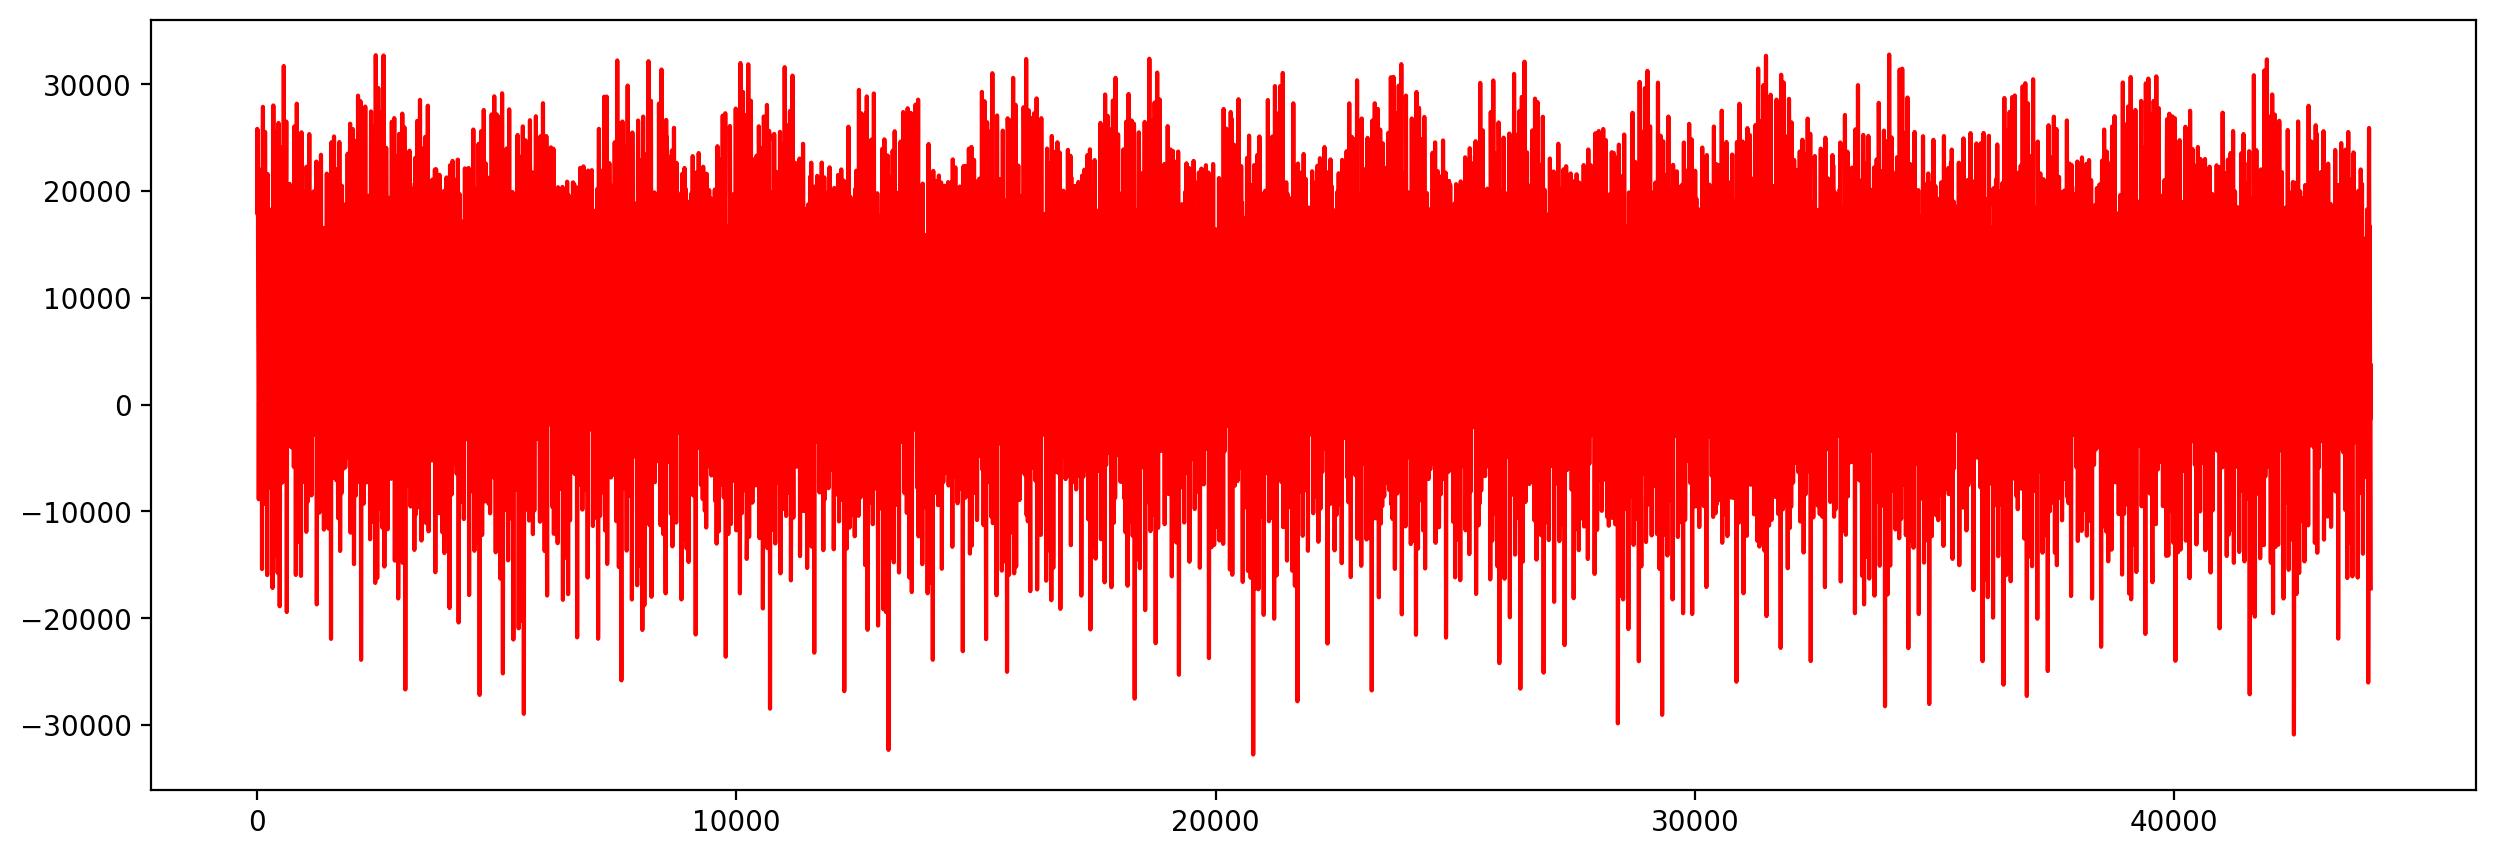

In [7]:
rate, data = wavfile.read(filename)
print("Data rate [units of Hz = 1/seconds] = ",rate)
PrintArrayInfo(data,"data")
plt.rcParams['figure.figsize'] = [15, 5]
plt.plot(data,'r-')
plt.show()

Data rate [units of Hz = 1/seconds] =  44100
Array: data
shape: (5000,)
dtype: int16
min, max: -27186 32709



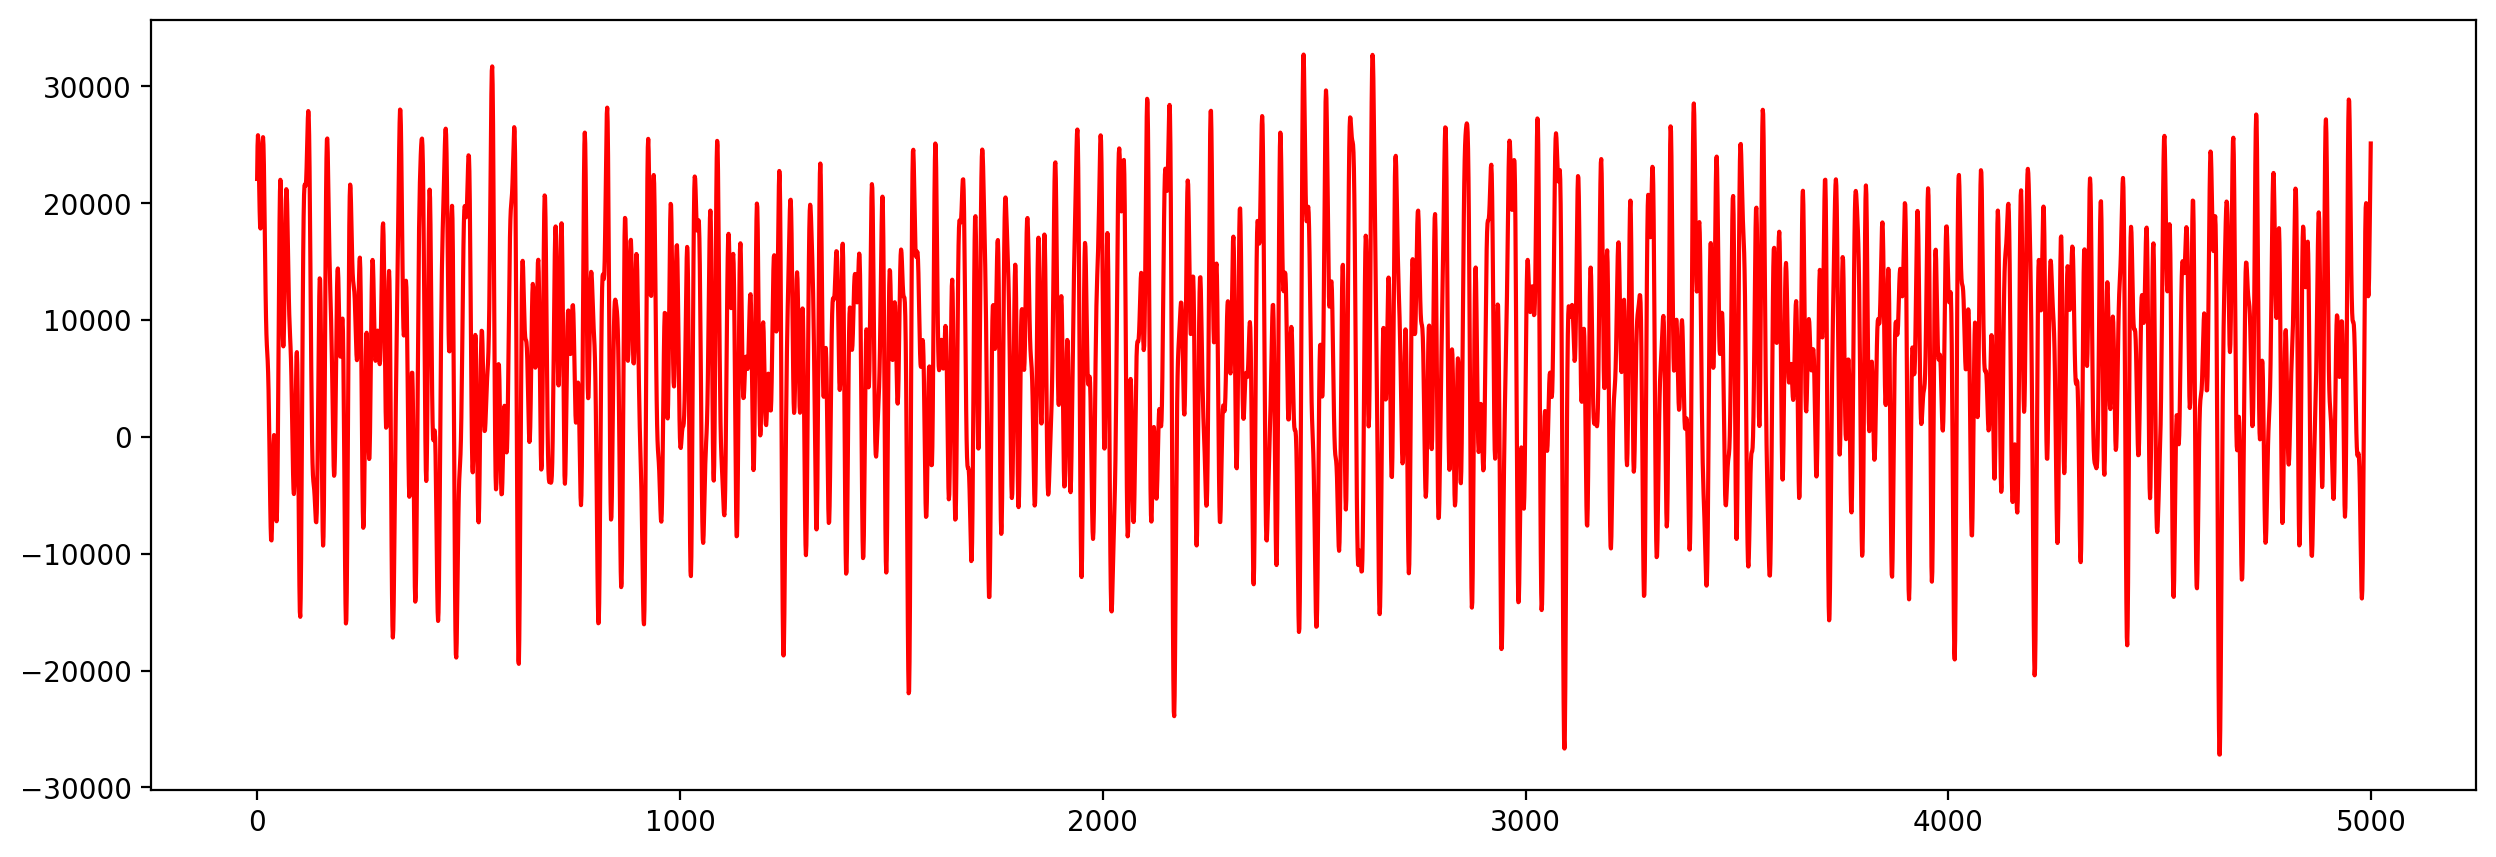

In [8]:
rate, data = wavfile.read(filename)
data = data[0:5000]
print("Data rate [units of Hz = 1/seconds] = ",rate)
PrintArrayInfo(data,"data")
plt.rcParams['figure.figsize'] = [15, 5]
plt.plot(data,'r-')
plt.show()

In [9]:
n = 5000
fsin = 0
fcos = 0
k = 1

for j in range(n):
  fsin += data[j]*np.sin(2*np.pi*j*k/n)
for j in range(n):
  fcos += data[j]*np.cos(2*np.pi*j*k/n)
sum = fsin**2+fcos**2
print(sum)

38406571423.202194


In [10]:
n = 5000
def fk(data,k):
  fsin = 0
  fcos = 0
  for j in range(n):
    fsin += data[j]*np.sin(2*np.pi*j*k/n)
  for j in range(n):
    fcos += data[j]*np.cos(2*np.pi*j*k/n)
  total = fsin**2 + fcos**2
  return total

In [11]:
fk(data, 1000)

np.float64(27302664.67713286)

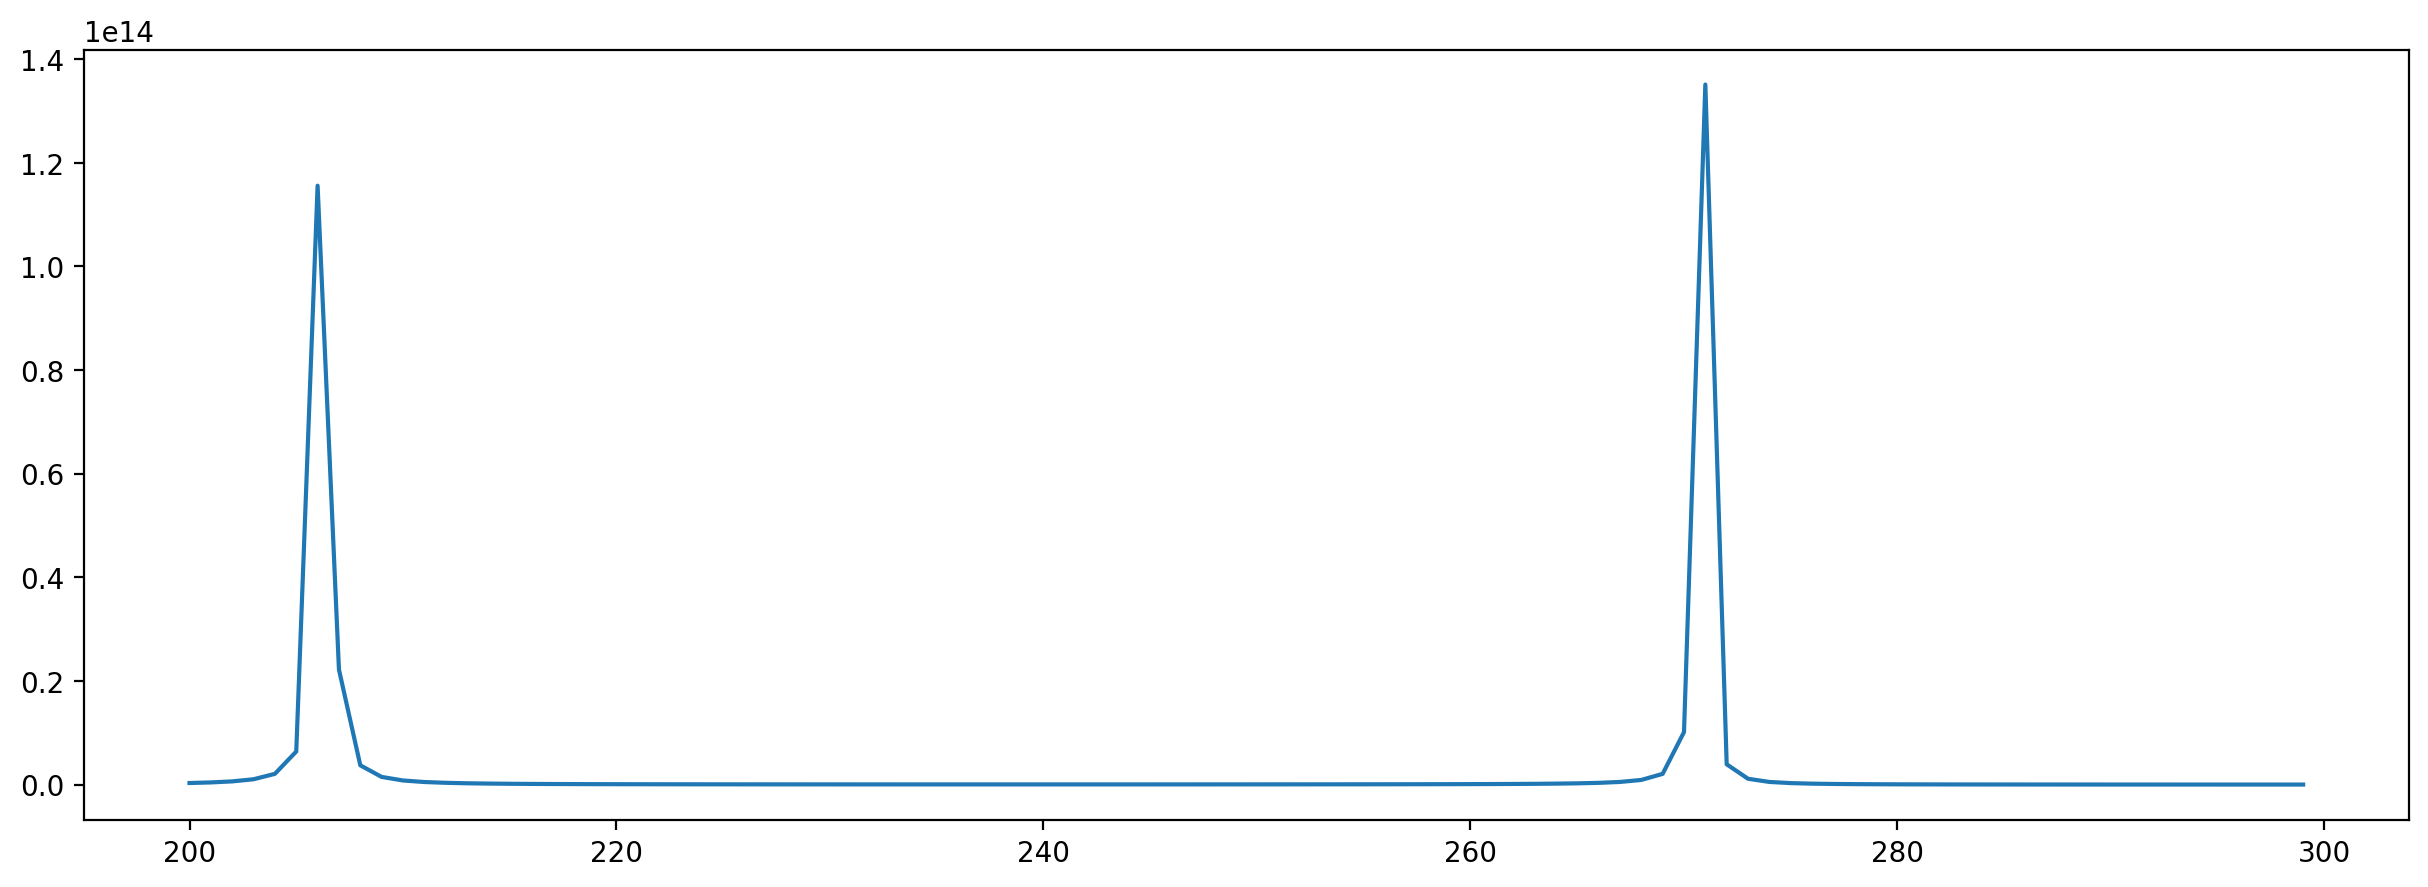

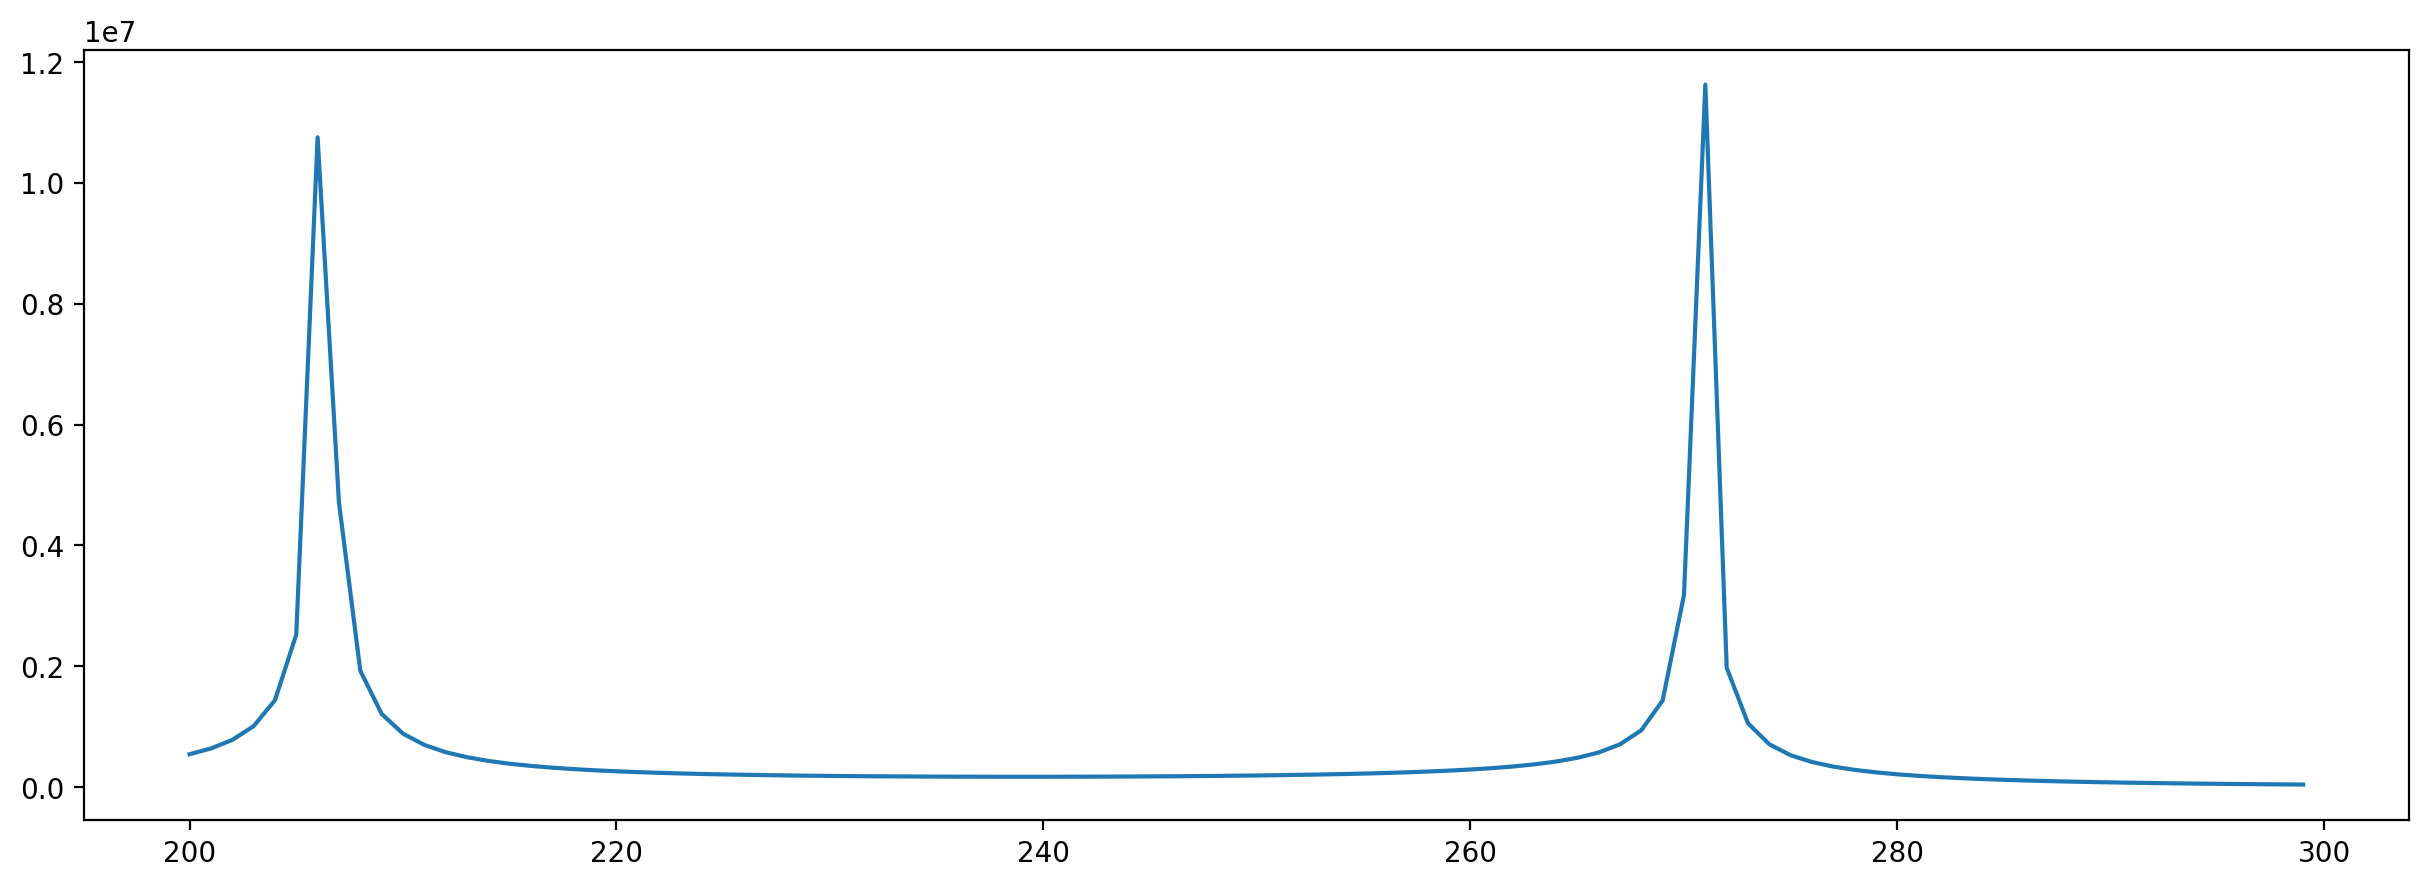

In [12]:
# For some reason off by 10^7 times. Maybe from (1/n)^2?
k = np.arange(200,300,1) # try 200 to 300. Original: 1100 to 1150
fkt = []
for i in range(len(k)):
  fkt.append(fk(data,k[i]))
plt.plot(k,fkt)
plt.show()
plt.plot(k,np.sqrt(fkt))
plt.show()

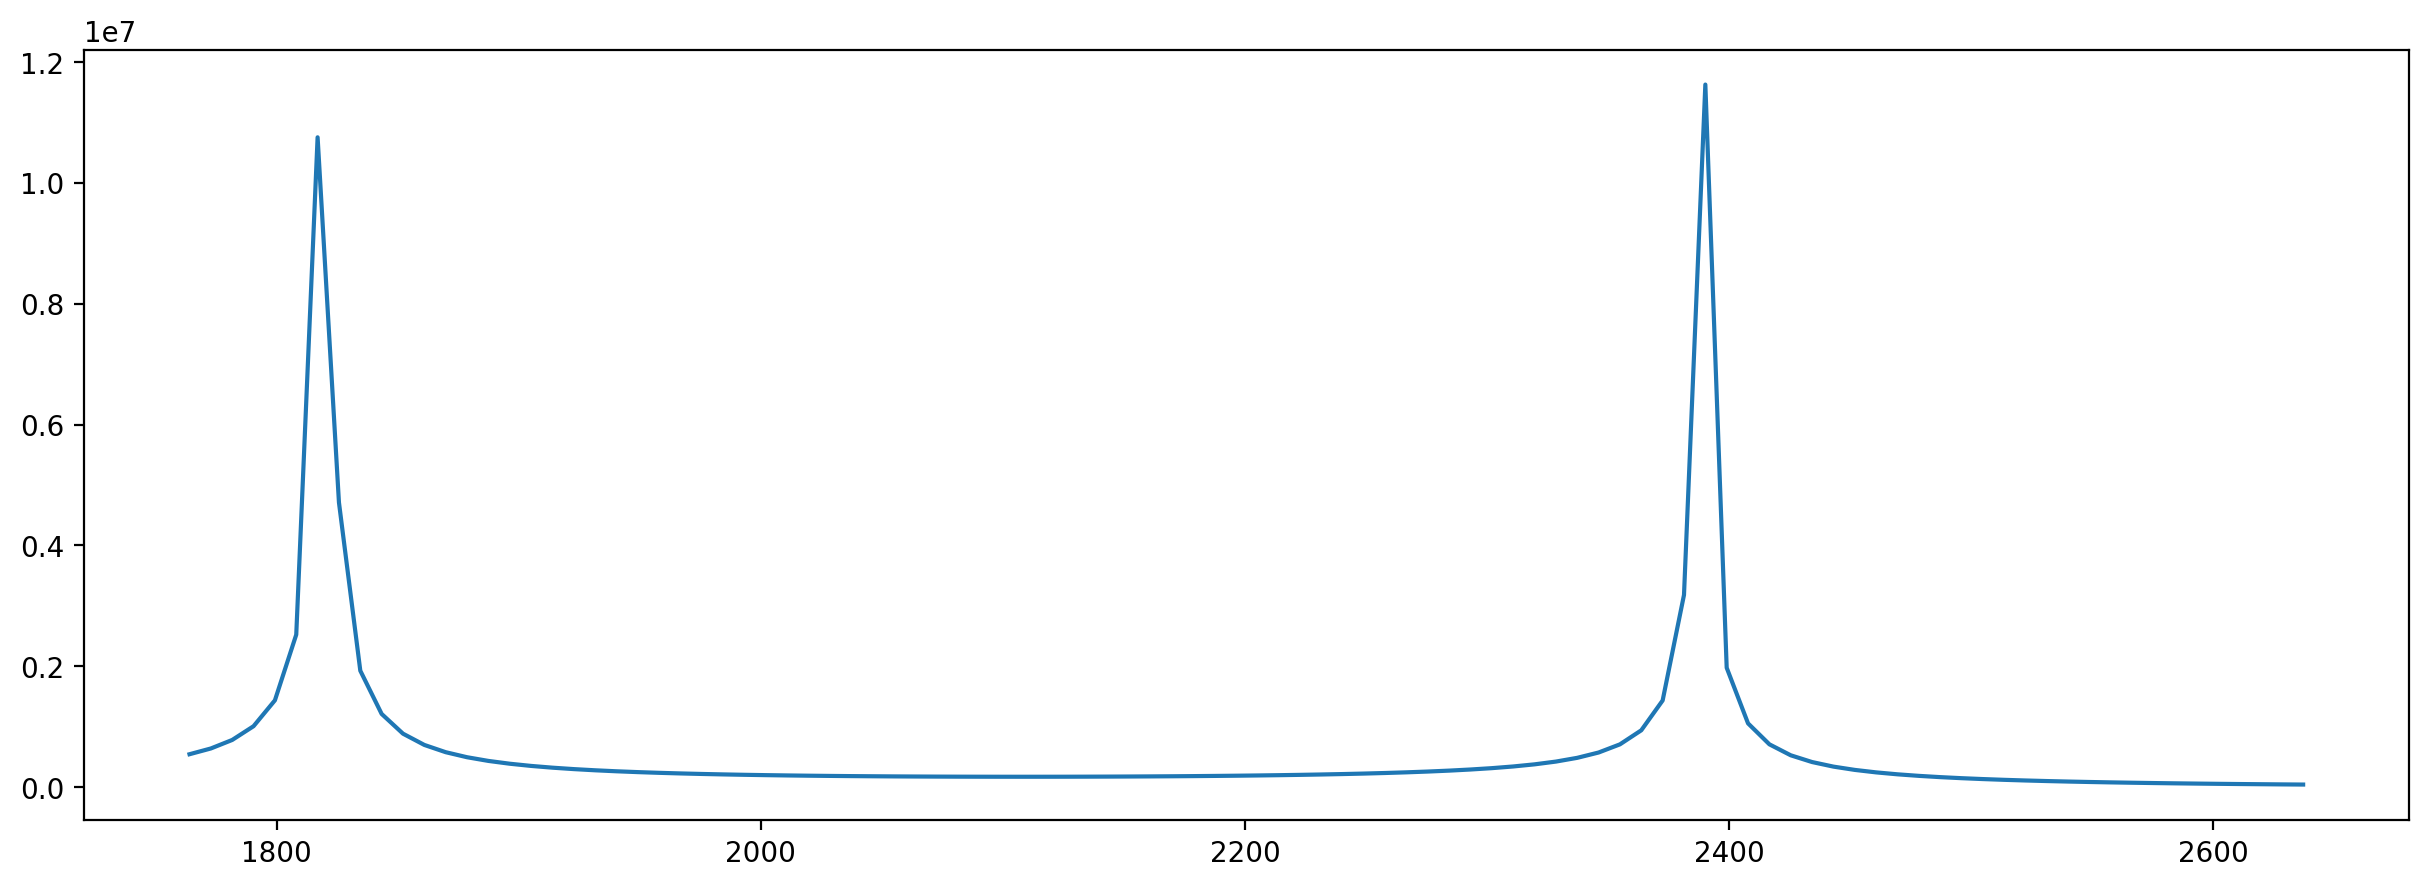

In [13]:
nu = k*44100/5000
plt.plot(nu, np.sqrt(fkt))
plt.show()

[35028577.           +0.j           195973.16891859-1043.30589714j
   196103.27486358-2104.3941338j  ...   196159.90293318+3182.02652165j
   196103.27486358+2104.3941338j    195973.16891859+1043.30589714j]
(5000,)


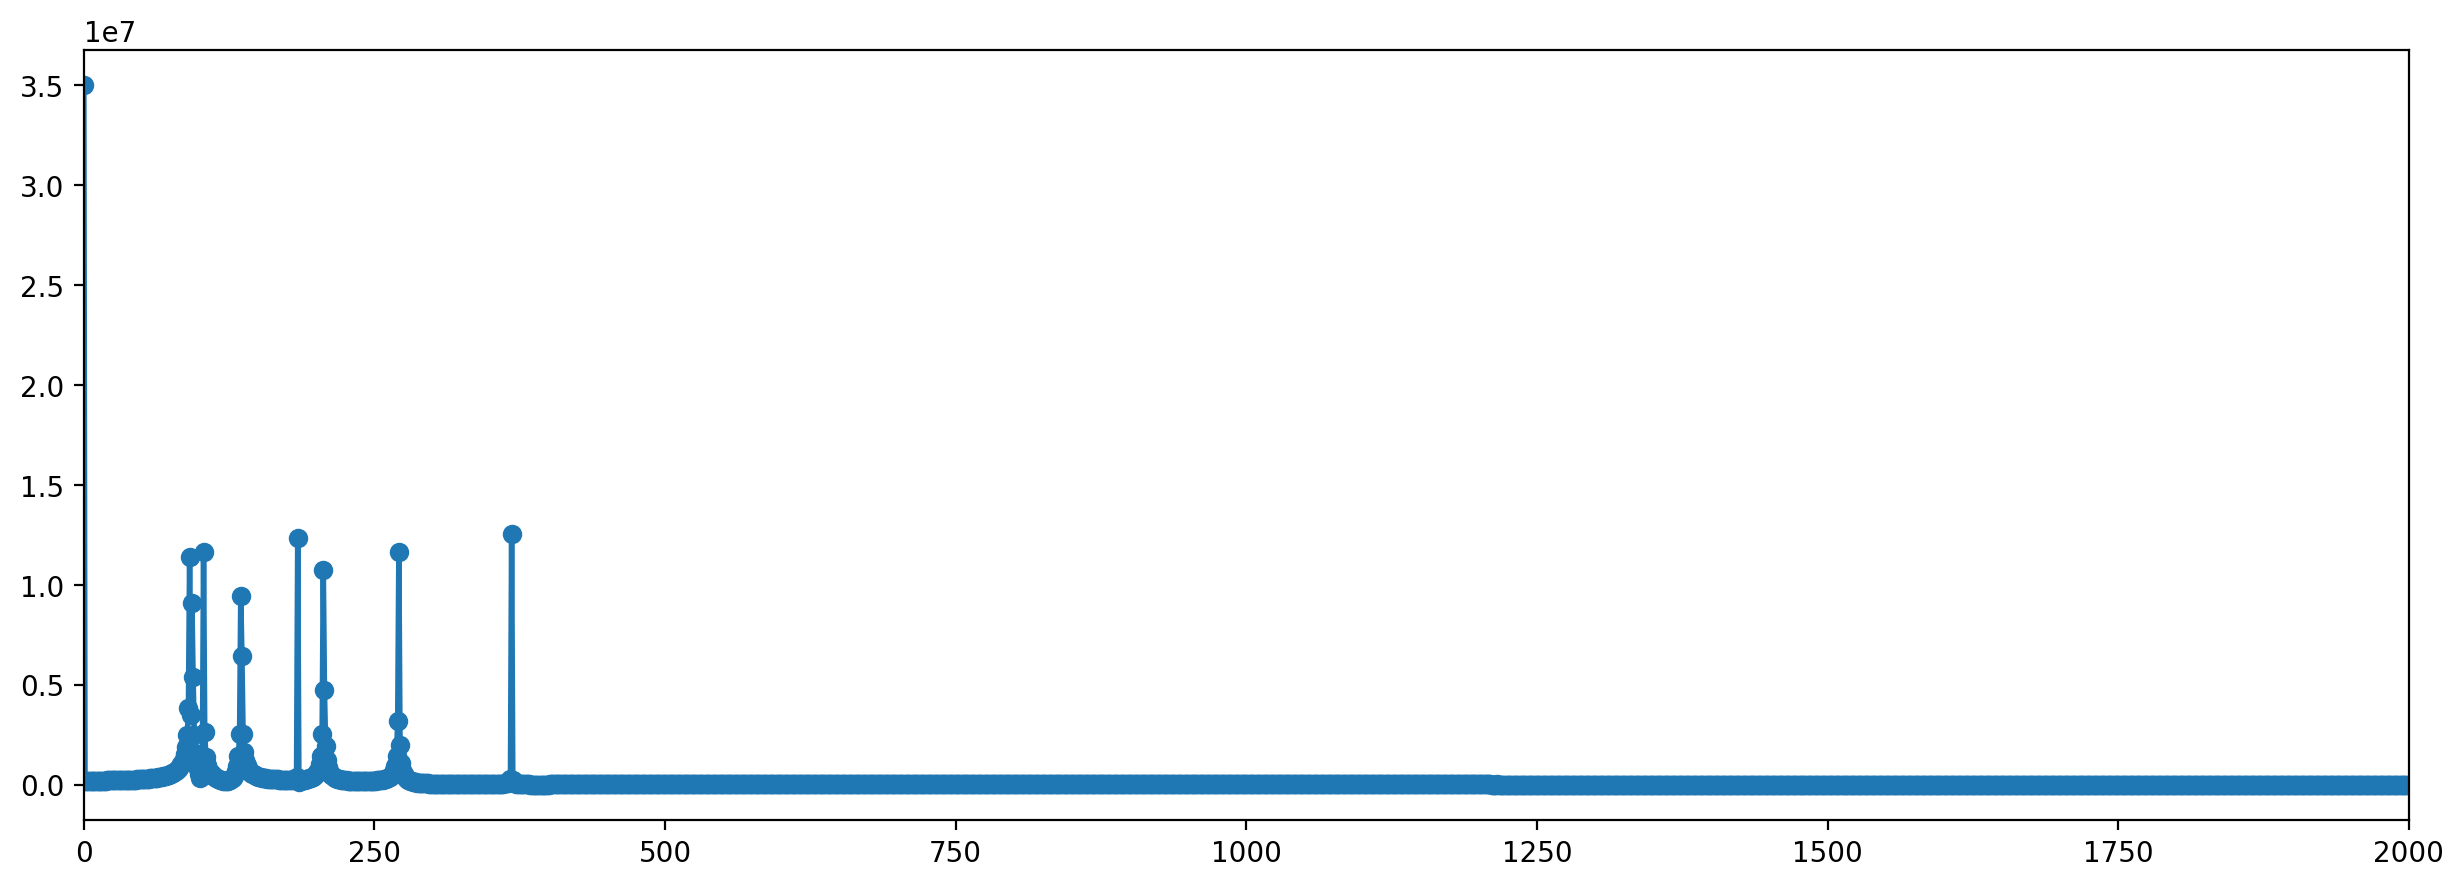

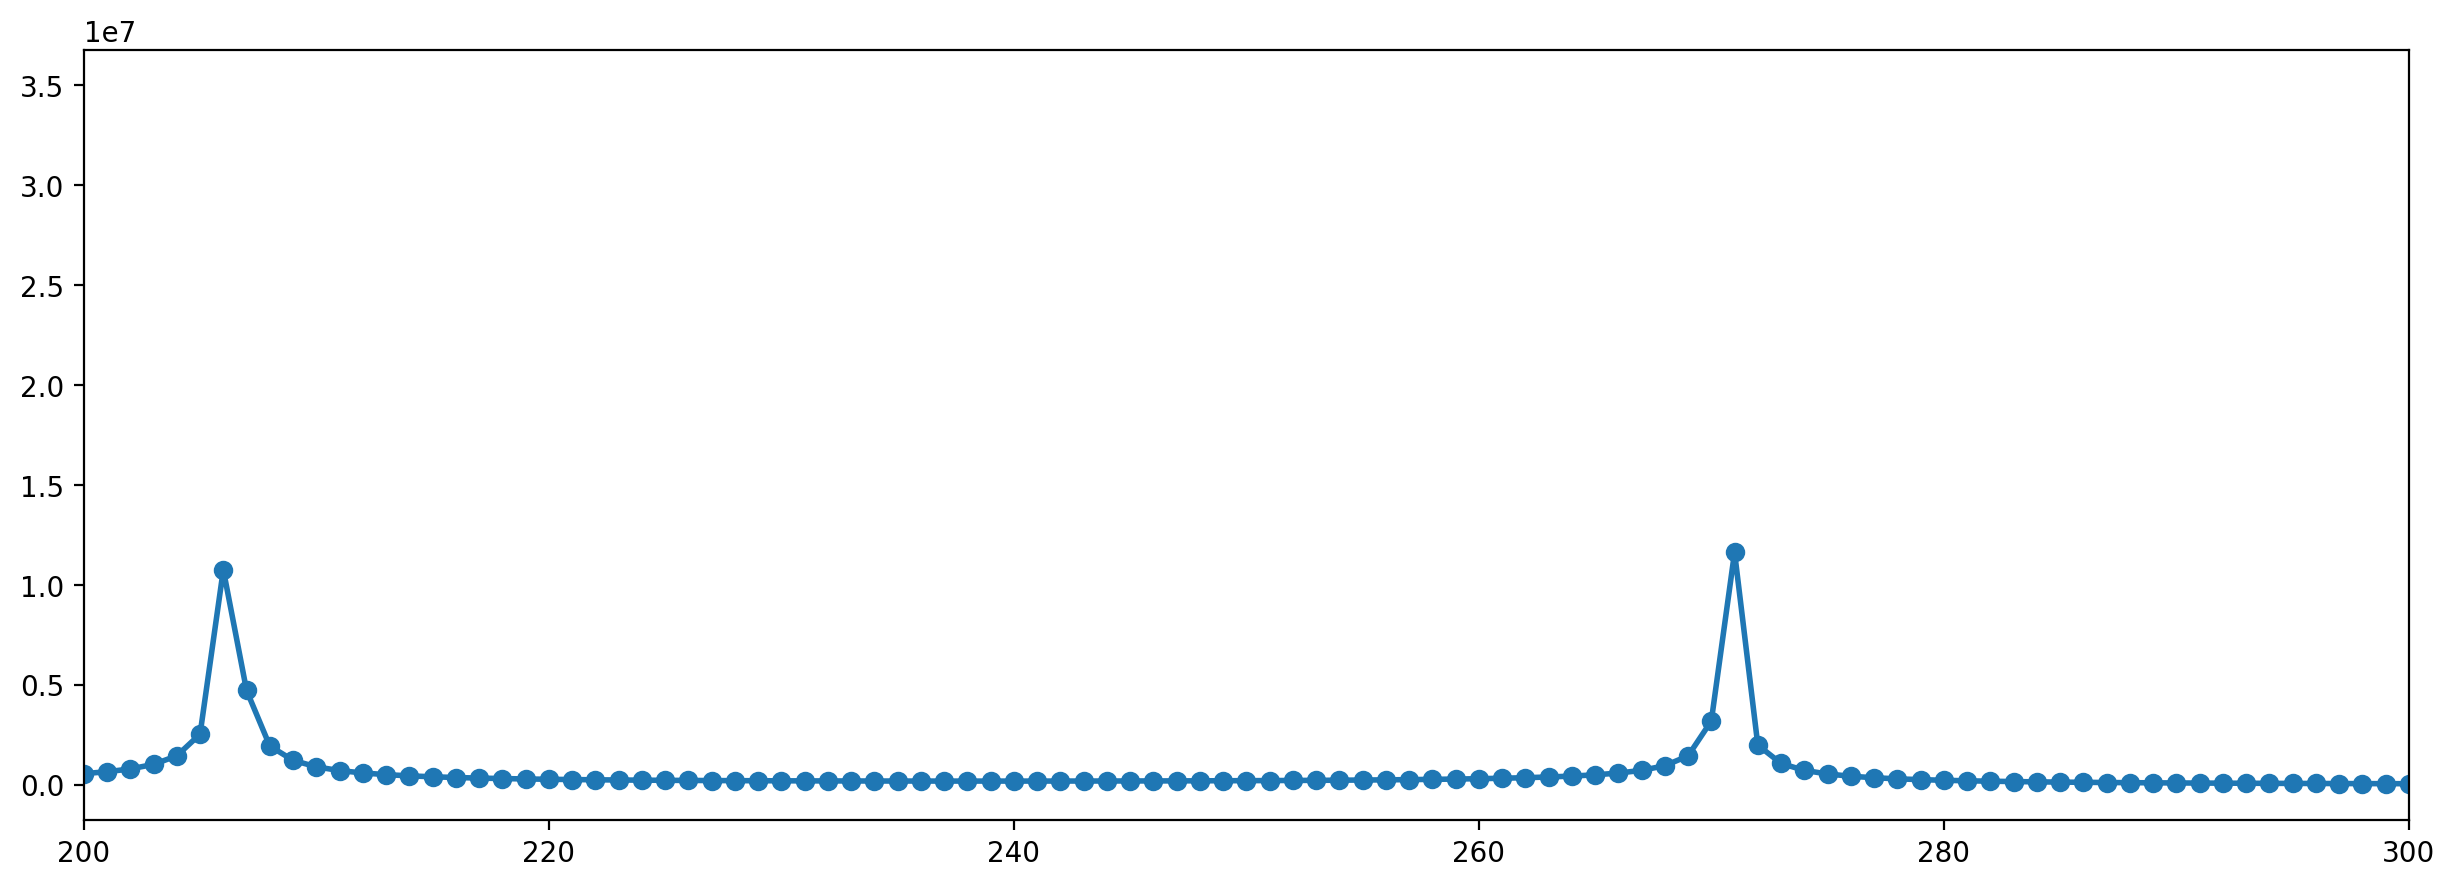

In [14]:
ft = np.fft.fft(data)
print(ft)
print(ft.shape)
plt.xlim(0,2000)
plt.plot(abs(ft), 'o-', lw=2)
plt.show()
plt.xlim(200,300) # more interesting around 200. originall, 1100 to 1150
plt.plot(abs(ft), 'o-', lw=2)
plt.show()

In [40]:
import numpy as np
import simpleaudio as sa

frequency = 440 # Play a tune A with a frequency of 440 Hz
fs = 44100 # 44100 samples per second
seconds = 2 # Duration of 2 seconds

# Generate array with seconds * sample_rate steps
t = np.linspace(0, seconds, seconds * fs, False)

# Generate a sine wave
note = np.sin(frequency * t * 2 * np.pi)

# Ensure that highest value is in 16-bit range
audio = note * (2**15 - 1) / np.max(np.abs(note))
# Convert to 16-bit data
audio = audio.astype(np.int16)

In [41]:
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'
import numpy as np
import simpleaudio as sa
from scipy.io import wavfile

In [42]:
def PrintArrayInfo(a, name=''):
  if(len(name) == 0):
    print("Array info:")
  else:
    print("Array:", name)
  print("shape:", a.shape)
  print("dtype:", a.dtype)
  print("min, max:", a.min(), a.max())
  print()

In [43]:
def Rescale(data):
  data2 = np.copy(data)
  dMin = data2.min()
  dMax = data2.max()
  dataRange = dMax-dMin # Warning: if you call this 'range', for loops will stop working
  data2 = (2**15-1) * (2.0*(data2-dMin) / dataRange - 1.0)
  data2 = data2.astype(np.int16)
  return data2

In [44]:
def Play(rate, data):
  # Start playback
  play_obj = sa.play_buffer(data, 1, 2, rate)
  # Wait for playback to finish before exiting
  play_obj.wait_done()

In [45]:
def write(filename, rate, data):
  wavfile.write(filename, rate, data)

In [46]:
rate, data = wavfile.read('Promenade_very_short_mono.wav')

Data rate [units of Hz = 1/seconds] =  88200
Array: data
shape: (394864,)
dtype: int16
min, max: -10087 10795



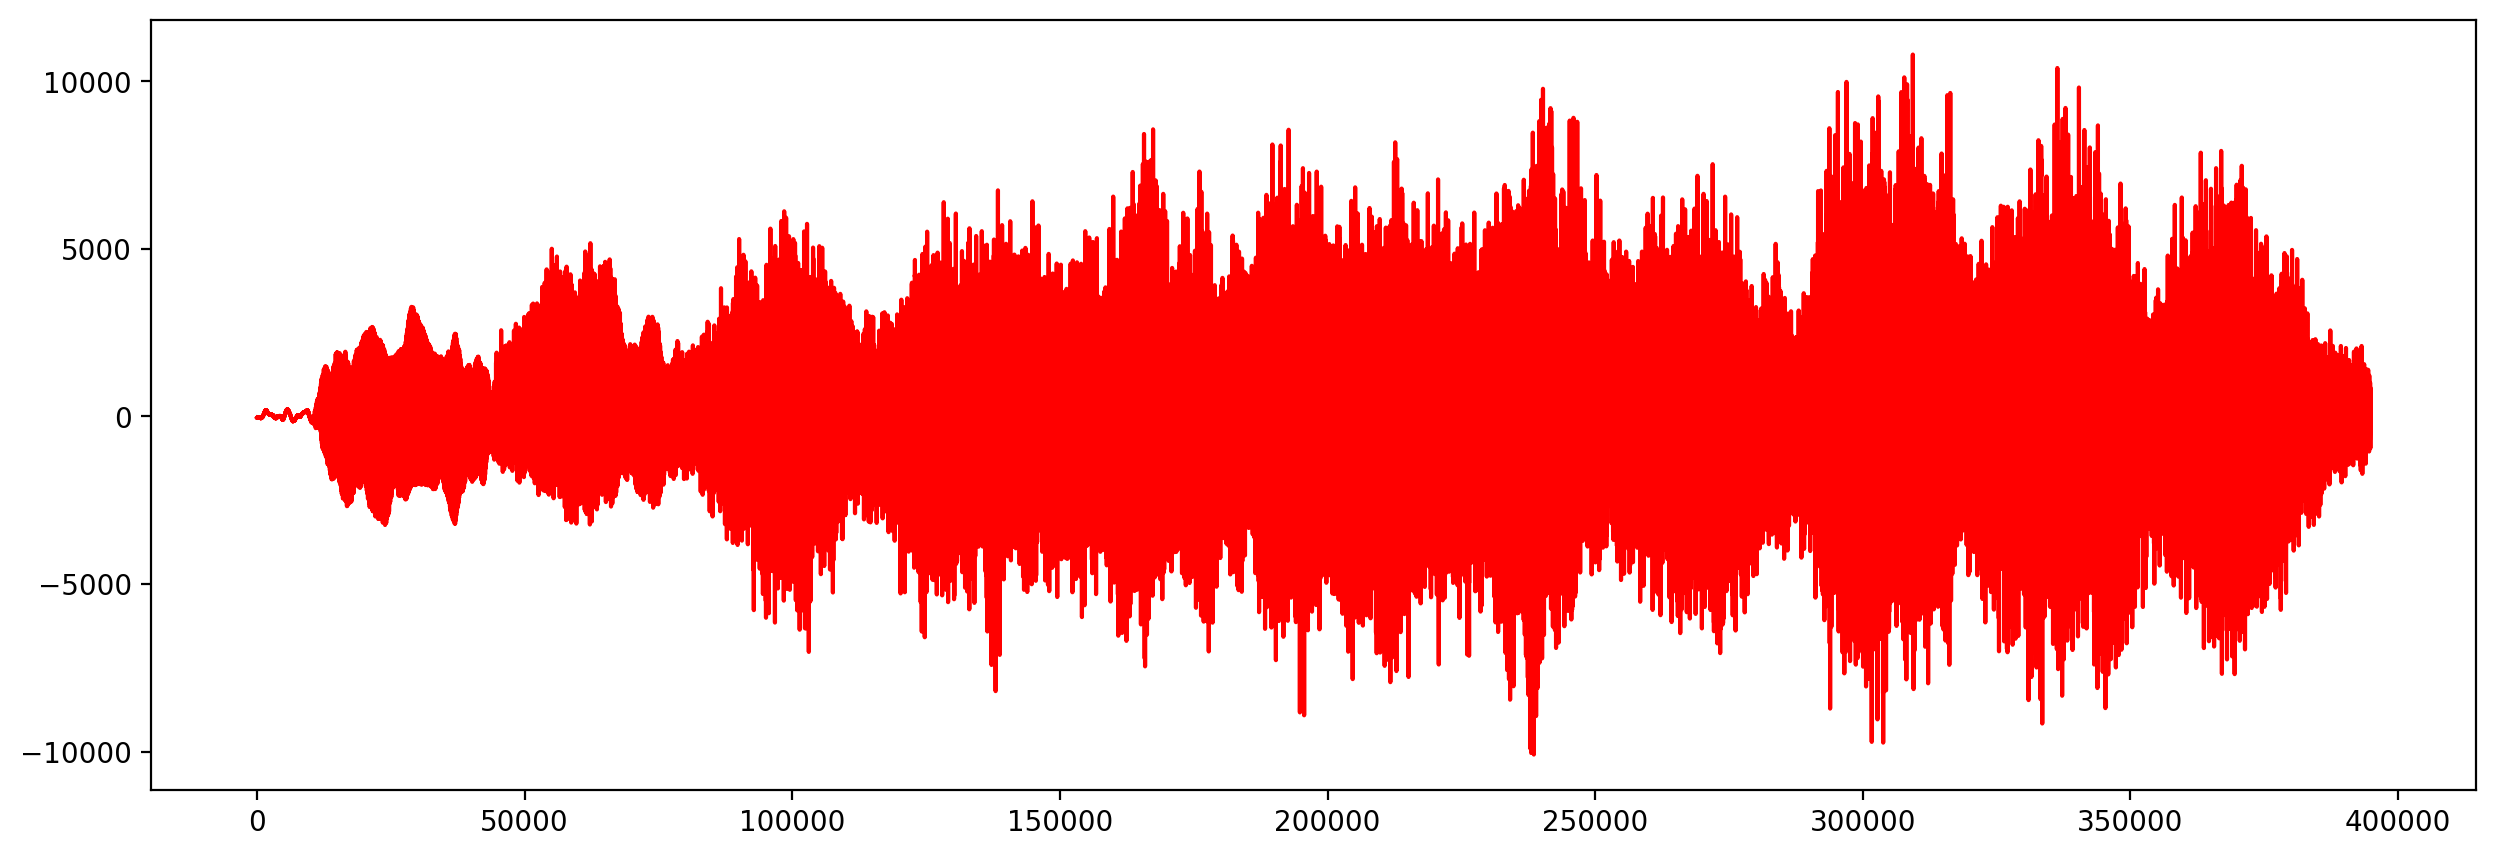

In [47]:
print("Data rate [units of Hz = 1/seconds] = ",rate)
PrintArrayInfo(data,"data")
plt.rcParams['figure.figsize'] = [15, 5]
plt.plot(data,'r-')
plt.show()
# total = 394864/44100 = 8.95 sec

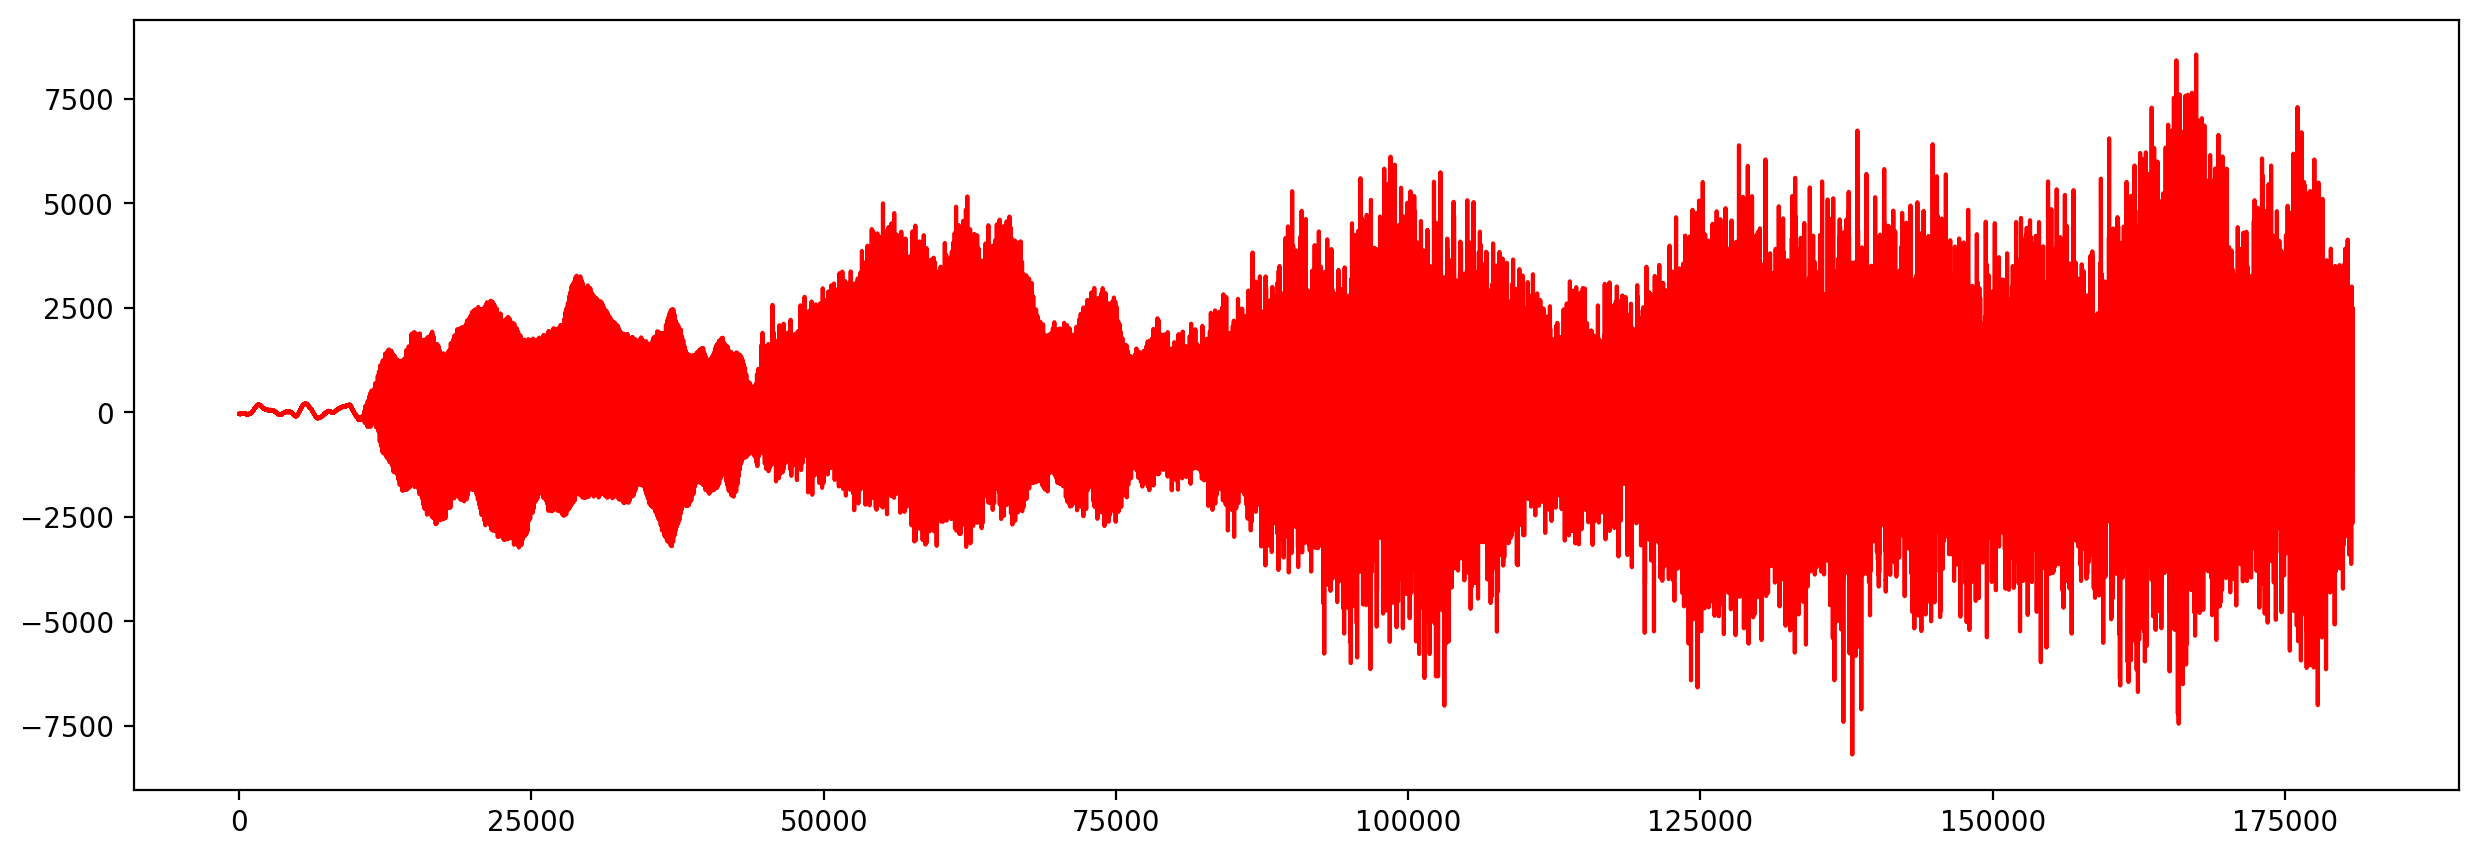

In [48]:
data0 = data[0:180810] # 44100 Hz*4.1 sec
plt.rcParams['figure.figsize'] = [15, 5]
plt.plot(data0,'r-')
plt.show()

(394864,)


ValueError: x and y must have same first dimension, but have shapes (180810,) and (394864,)

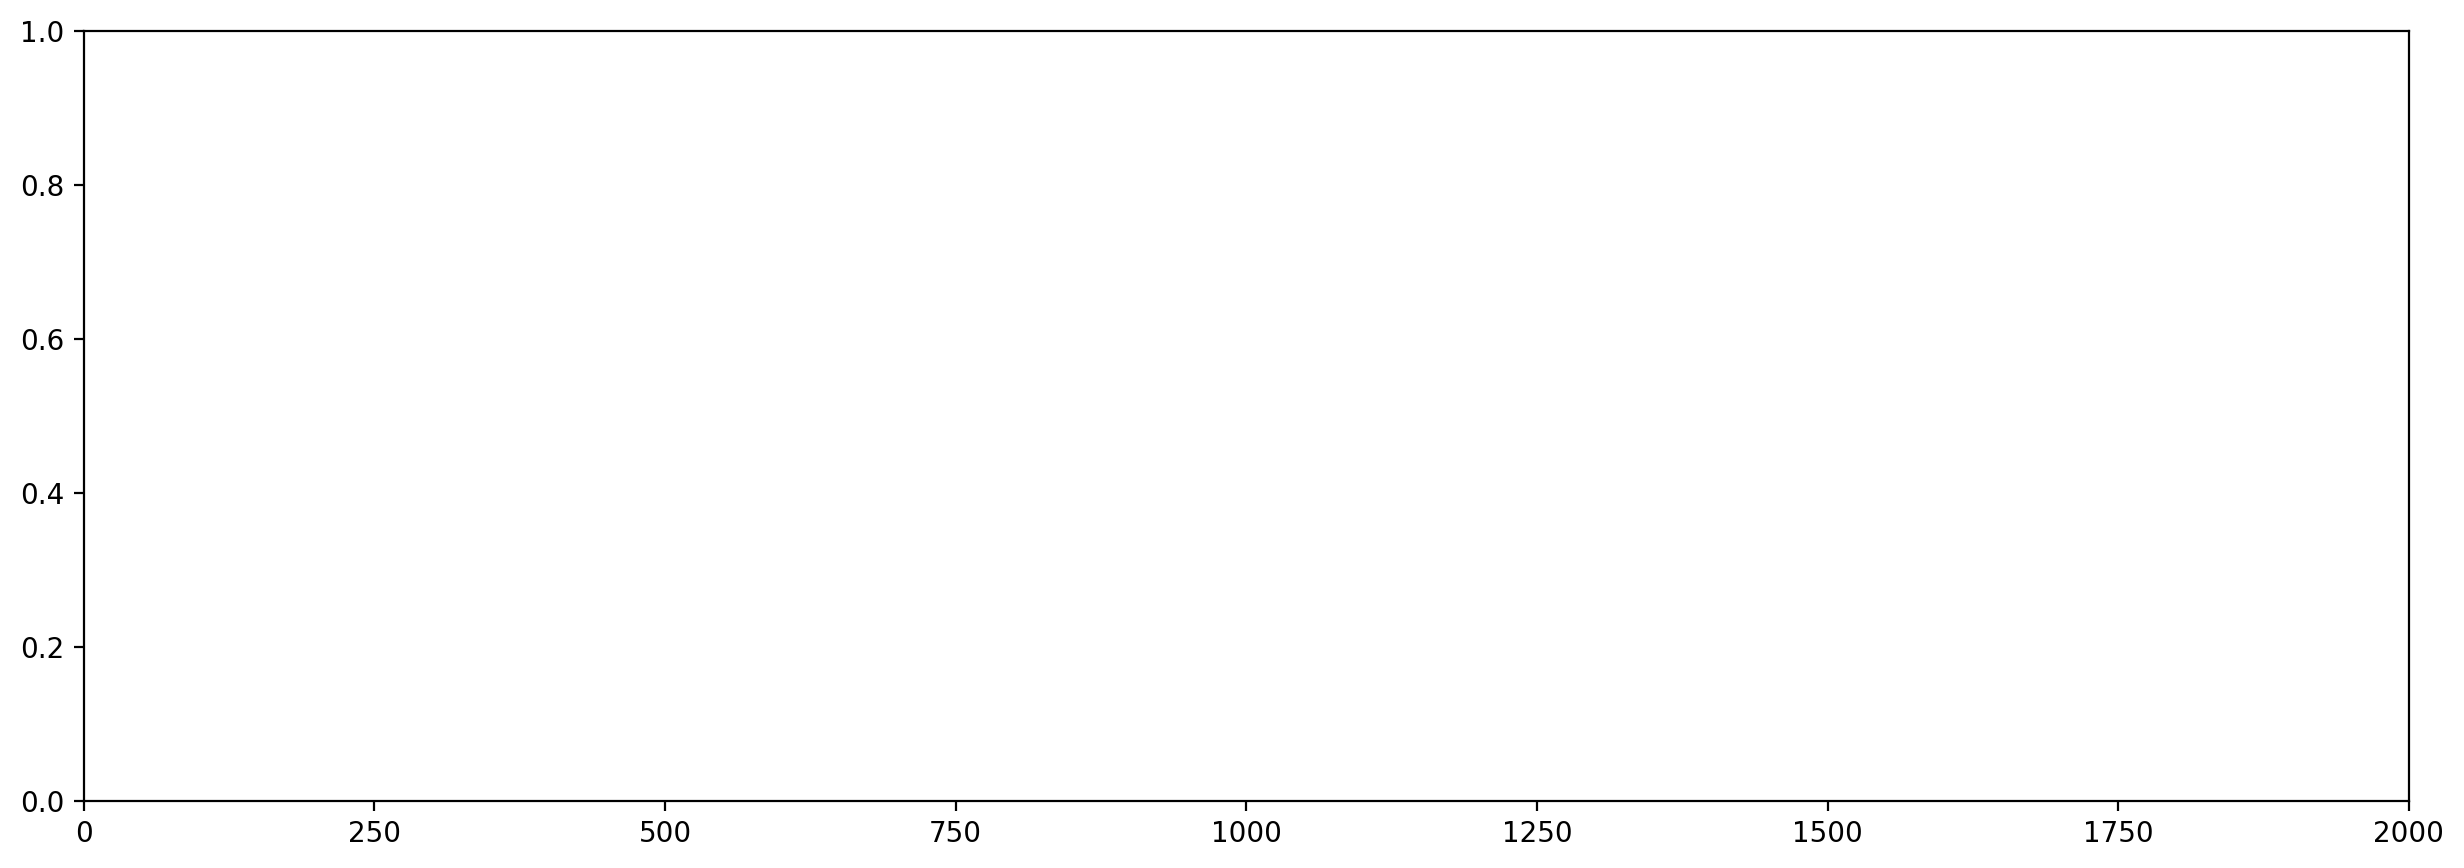

In [52]:
ft = np.fft.fft(data)
print(ft.shape)
k = np.arange(0, 180810) # might need to change. Redo this part. Figure out what k range corresponds to 1-3 kHz
nu = k*44100/5000
plt.xlim(0,2000)
plt.plot(nu,abs(ft), 'o-', lw=2)
plt.show()

(394864,)


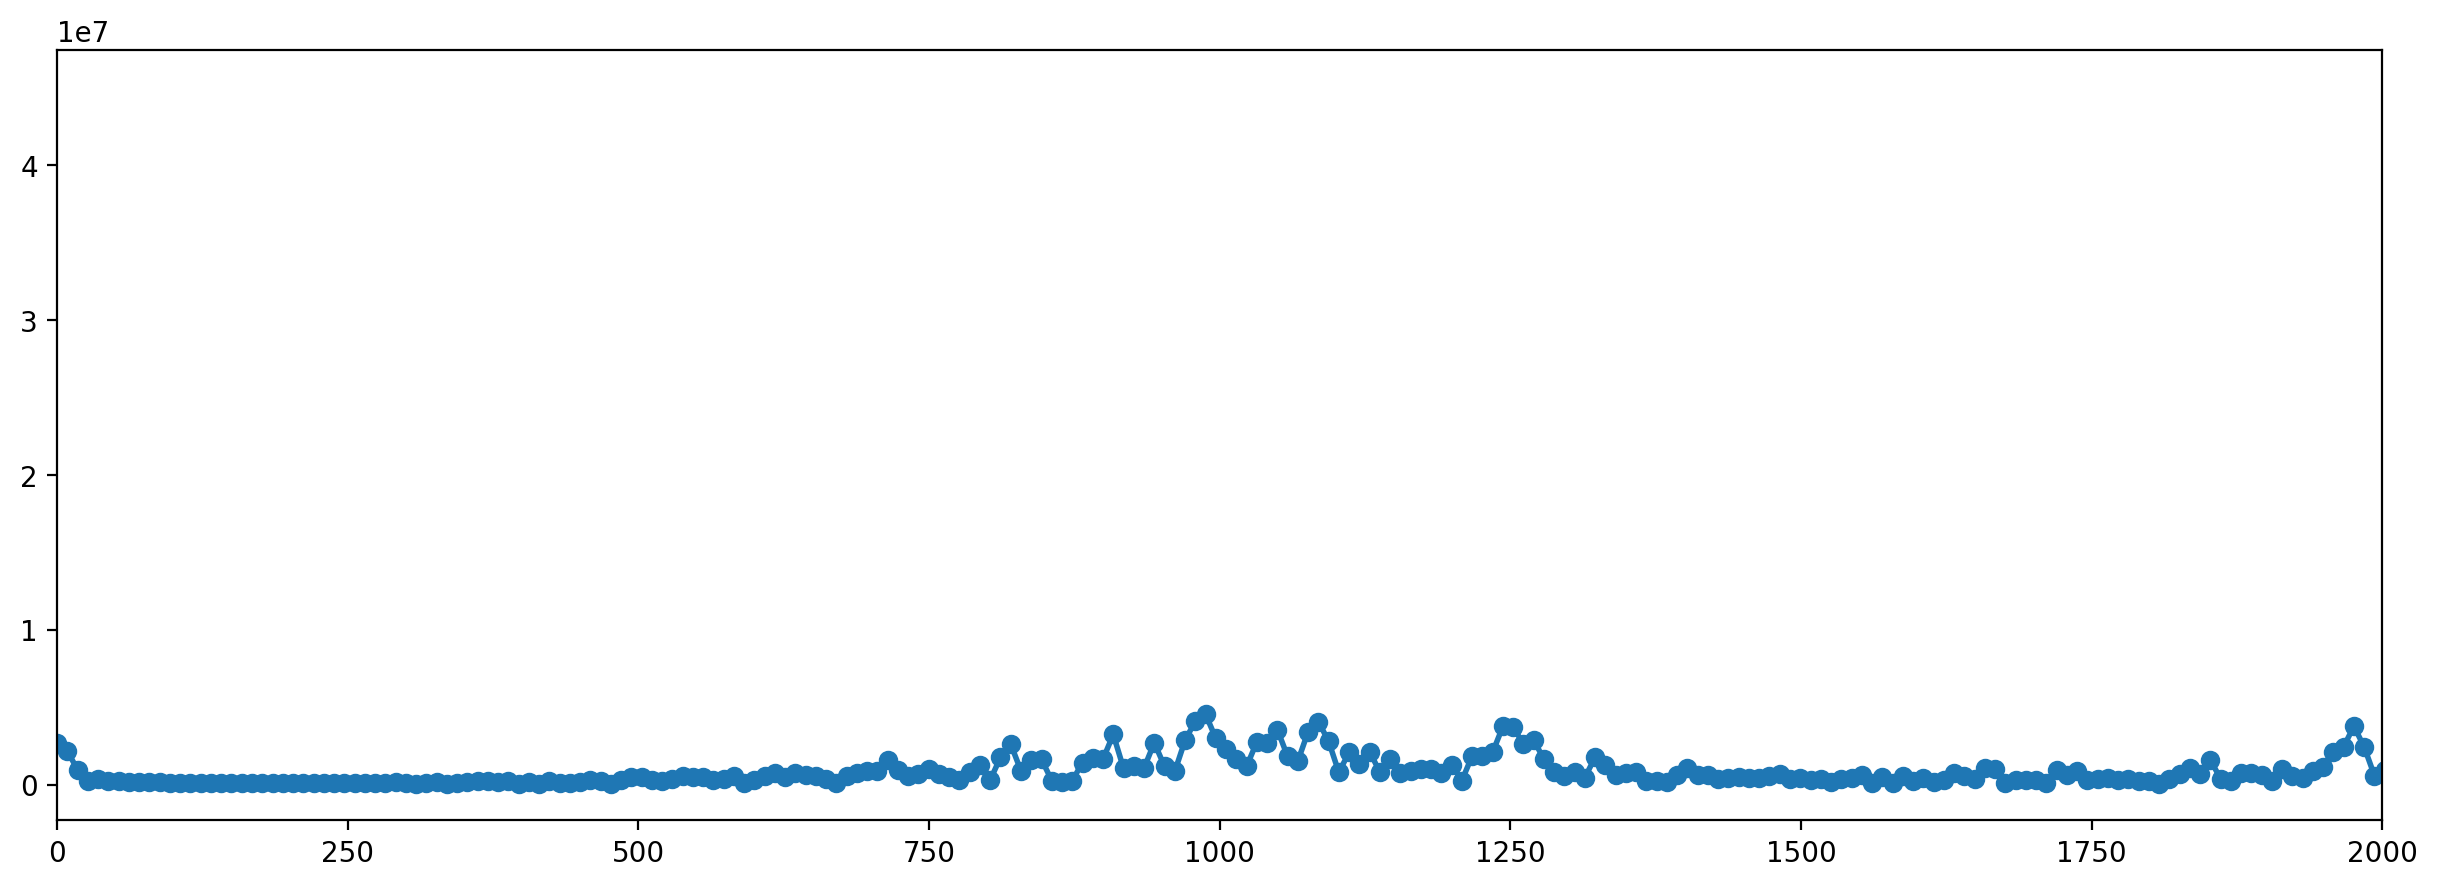

In [35]:
ft = np.fft.fft(data)
print(ft.shape)
k = np.arange(0, len(data)) # Changed k to match the length of data/ft
nu = k*44100/5000
plt.xlim(0,2000)
plt.plot(nu, abs(ft), 'o-', lw=2)
plt.show()

(180810,)


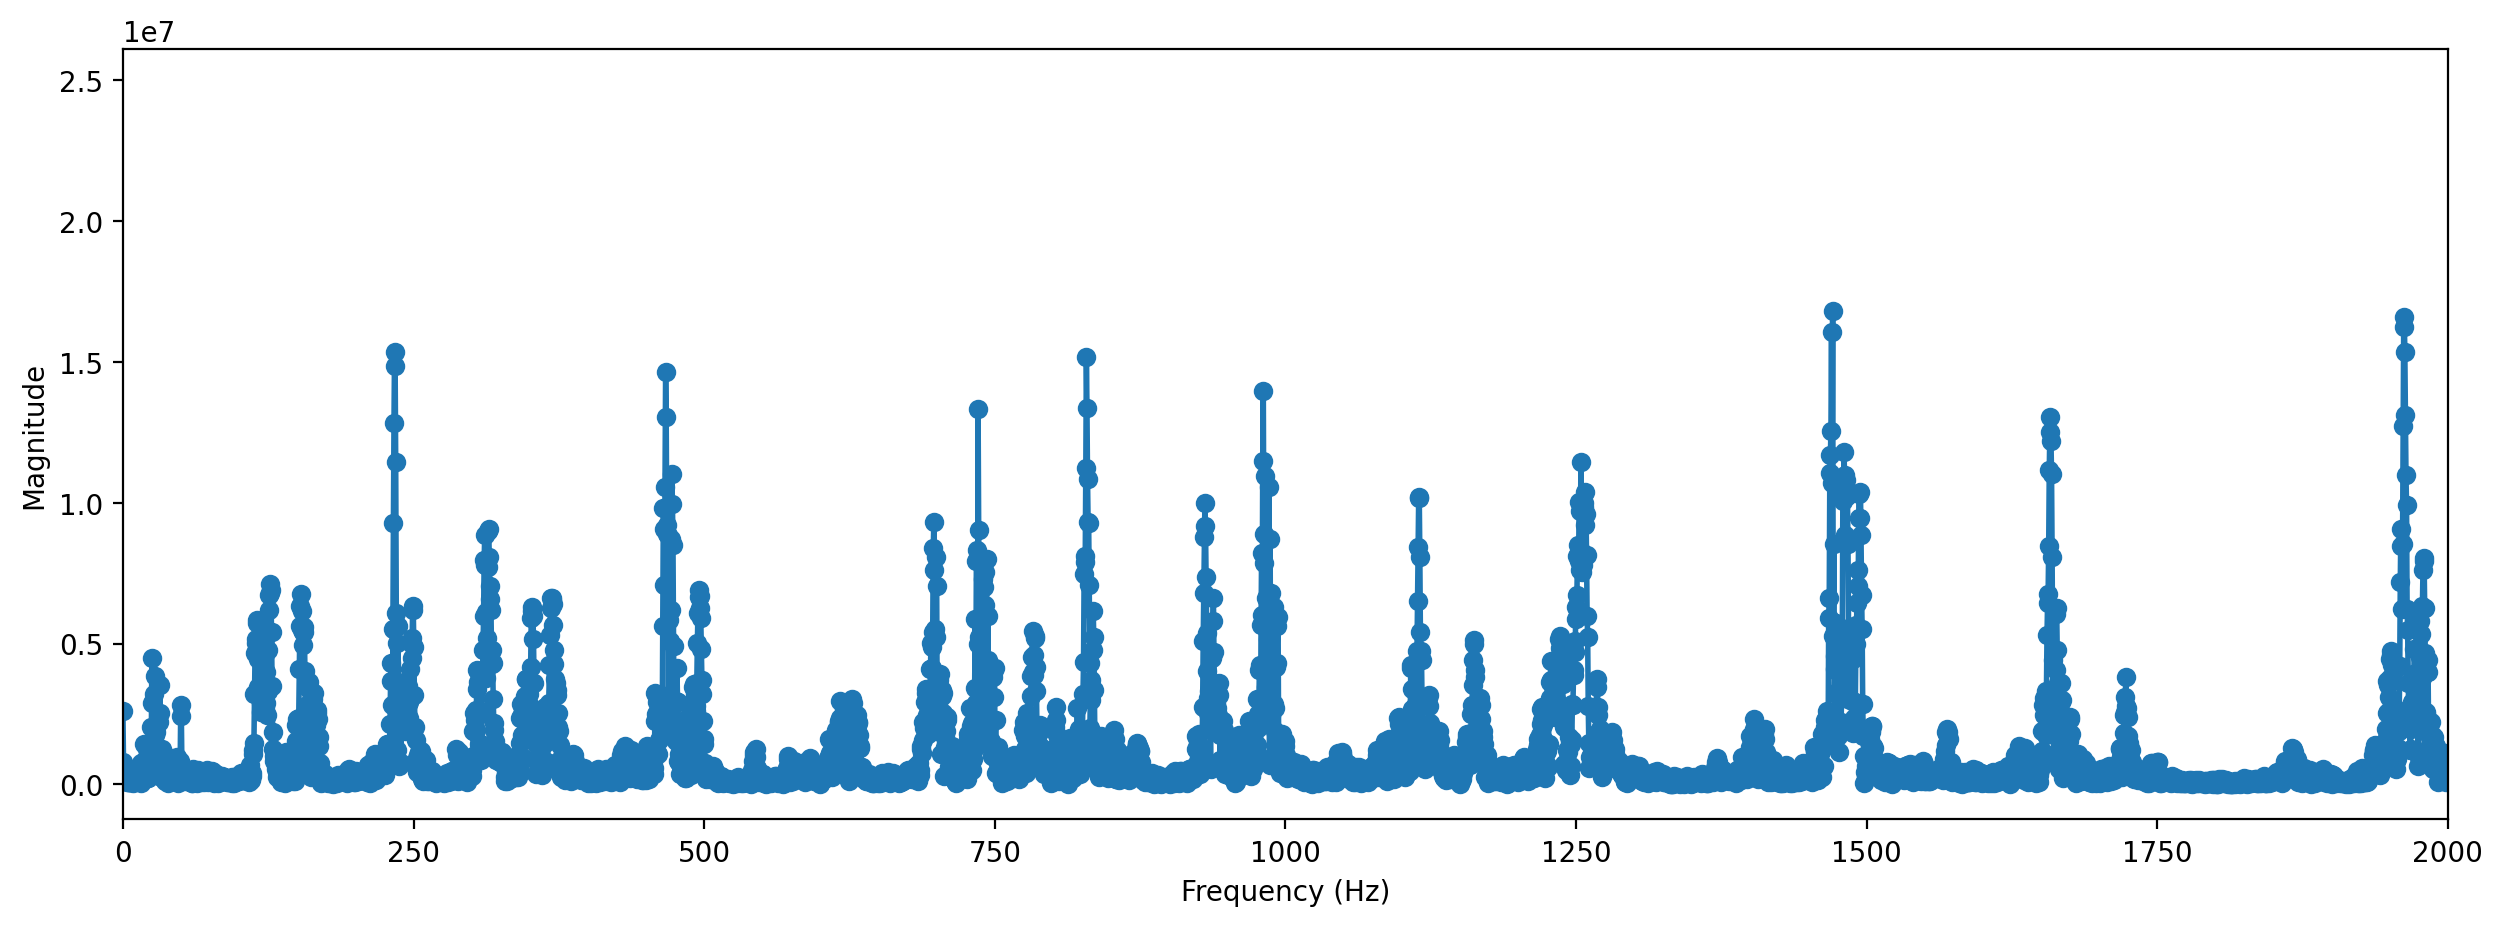

In [55]:
# FFT of selected audio segment
fs = rate # 44100 Hz
data_fft = data0

N = len(data_fft)
ft = np.fft.fft(data_fft)
print(ft.shape)

k = np.arange(0, N)
nu = k * fs / N

plt.figure(figsize=(15,5))
plt.xlim(0,2000)
plt.plot(nu, abs(ft), 'o-', lw=2)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()

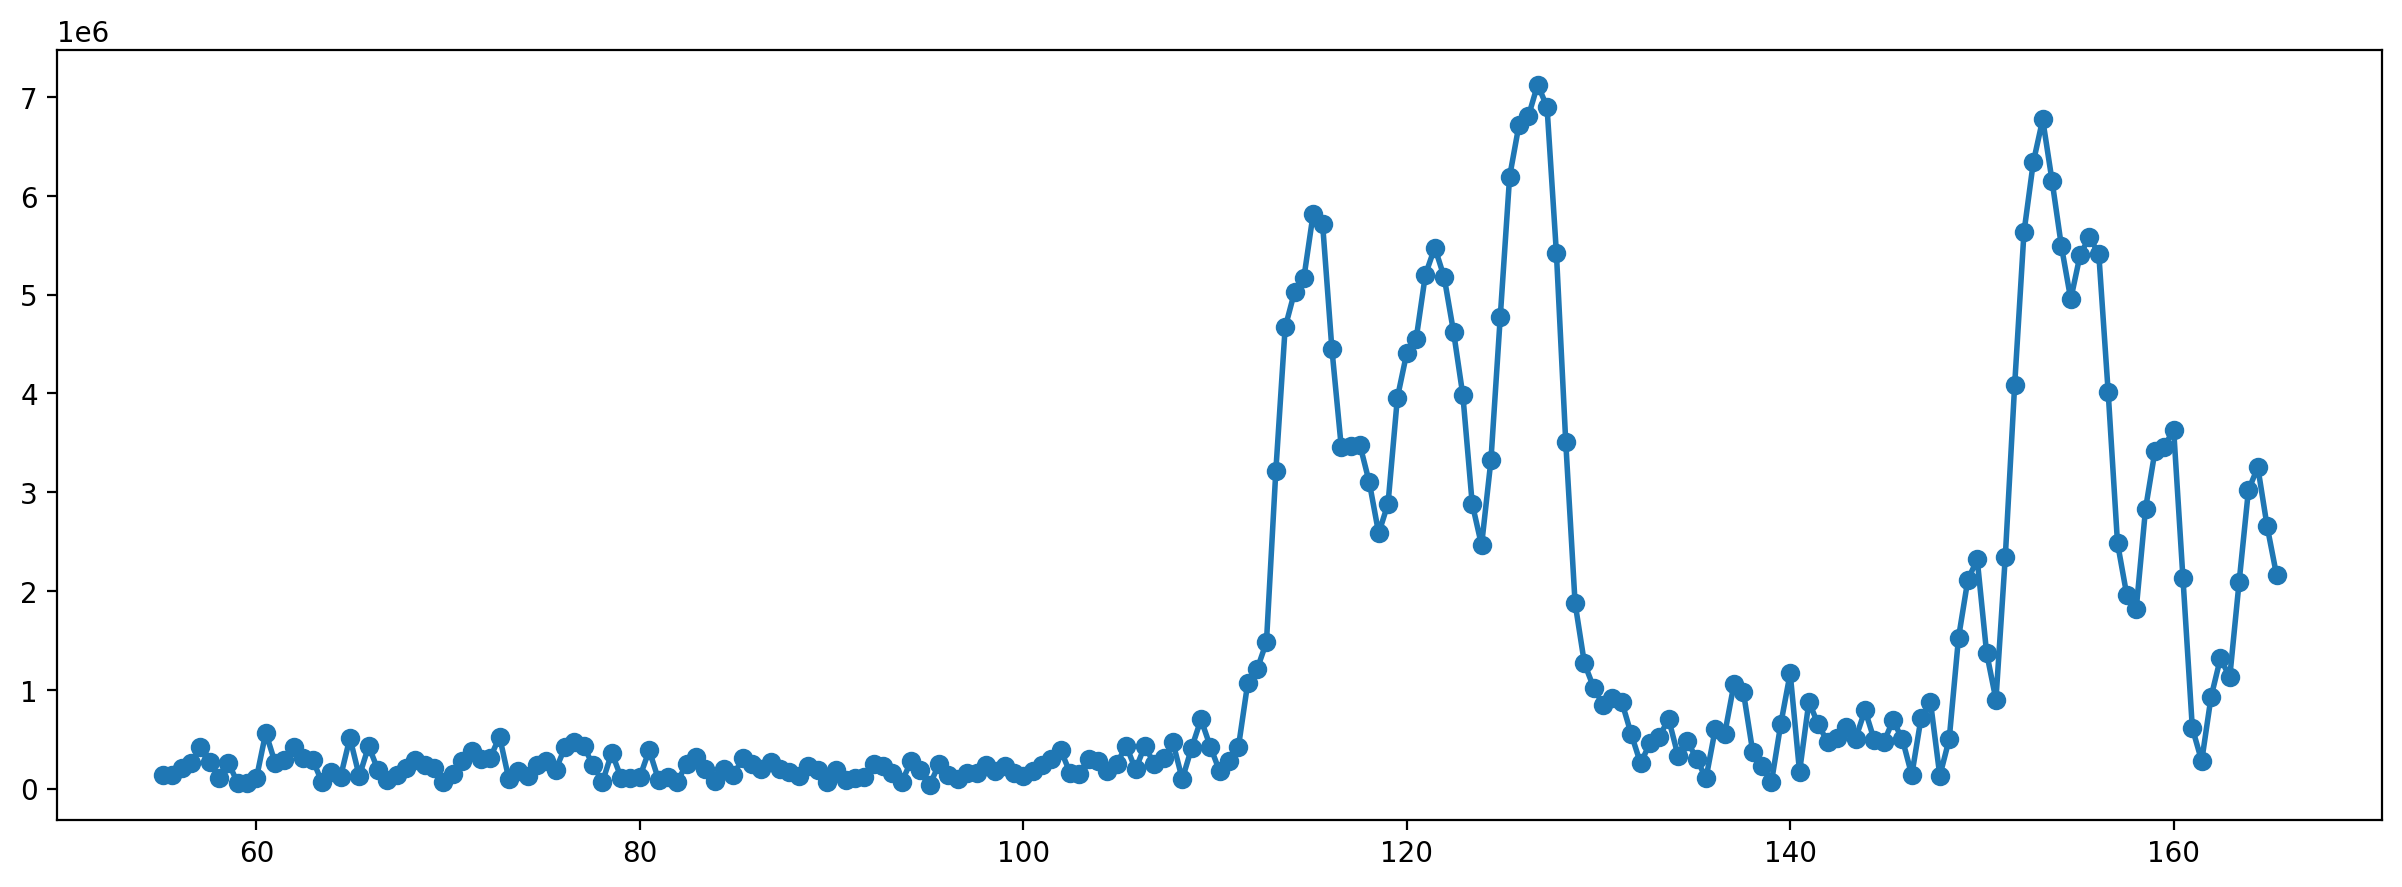

In [56]:
# 1000Hz=1000*5000/44100 = 113.37 = 113th (this is k)
# 3000 = 340th (this is k)
nu = nu[113:340]
ft = ft[113:340]
plt.plot(nu, abs(ft), 'o-', lw=2)
plt.show()

In [38]:
data2 = np.fft.ifft(ft)
data3 = Rescale(data2.real)

In [39]:
wavfile.write('Promenade_very_short_mono.wav', rate*2, data)